# Climate-blind source-coordinate and UTC-onset audit

This notebook reads only the frozen discovery selector and the registered audit layer. It does not load atmospheric, glacier-change, or permafrost data. Hollow symbols are catalog points; filled symbols are independently accepted source coordinates.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'data' / 'candidates.csv').exists():
    ROOT = ROOT.parent
assert (ROOT / 'data' / 'candidates.csv').exists()
AUDIT = ROOT / 'data' / 'event_audit'
summary = pd.read_csv(AUDIT / 'summary.csv')
times = pd.read_csv(AUDIT / 'time_assertions.csv')
candidates = pd.read_csv(ROOT / 'data' / 'candidates.csv')
candidates = candidates.query("consensus_decision == 'include' and trigger_time_eligible == 'yes'")
audit = summary.merge(candidates[['candidate_id', 'discovery_source']], on='candidate_id', validate='one_to_one')
assert len(audit) == 53 and audit['candidate_id'].is_unique
forbidden = {'warm_rank', 'temperature', 'era5', 'permafrost', 'glacier_change'}
assert not forbidden.intersection({column.lower() for column in audit.columns})
accepted_xy = audit.query("coordinate_status == 'accepted'").copy()
accepted_t = audit.query("time_status == 'accepted'").copy()


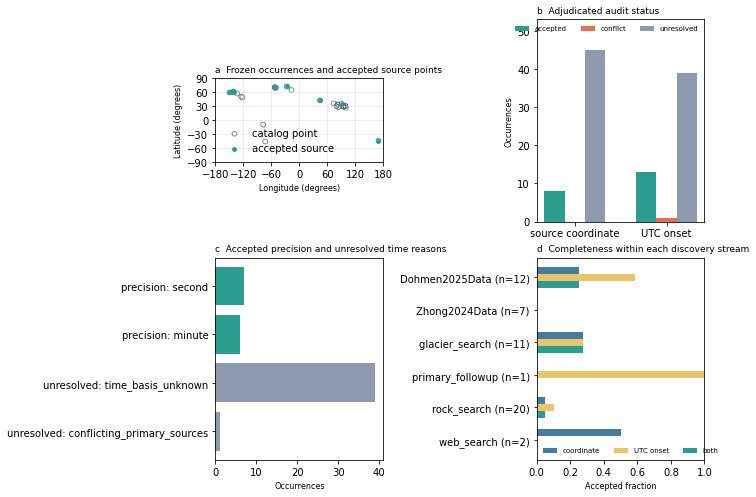

In [2]:
plt.rcParams.update({'font.size': 8, 'axes.titlesize': 9, 'axes.labelsize': 8})
colors = {'accepted': '#2a9d8f', 'conflict': '#e76f51', 'unresolved': '#8d99ae'}
fig, axes = plt.subplots(2, 2, figsize=(10, 6.8), constrained_layout=True)
ax = axes[0, 0]
original_xy = audit.dropna(subset=['original_longitude_deg', 'original_latitude_deg'])
ax.scatter(original_xy['original_longitude_deg'], original_xy['original_latitude_deg'],
           s=24, facecolors='none', edgecolors='#566573', linewidths=0.7, label='catalog point')
if len(accepted_xy):
    for row in accepted_xy.dropna(subset=['original_longitude_deg', 'original_latitude_deg']).itertuples():
        ax.plot([row.original_longitude_deg, row.audited_longitude_deg],
                [row.original_latitude_deg, row.audited_latitude_deg], color='#b0b7bd', lw=0.5, zorder=1)
    ax.scatter(accepted_xy['audited_longitude_deg'], accepted_xy['audited_latitude_deg'],
               s=14, color=colors['accepted'], label='accepted source', zorder=3)
ax.set(xlim=(-180, 180), ylim=(-90, 90), xticks=np.arange(-180, 181, 60),
       yticks=np.arange(-90, 91, 30), xlabel='Longitude (degrees)', ylabel='Latitude (degrees)')
ax.grid(color='#d9dde1', lw=0.5); ax.set_aspect('equal', adjustable='box')
ax.legend(frameon=False, loc='lower left'); ax.set_title('a  Frozen occurrences and accepted source points', loc='left')

ax = axes[0, 1]
status_order = ['accepted', 'conflict', 'unresolved']
x = np.arange(2); width = 0.22
for index, status in enumerate(status_order):
    values = [(audit[field] == status).sum() for field in ['coordinate_status', 'time_status']]
    ax.bar(x + (index - 1) * width, values, width, color=colors[status], label=status)
ax.set(xticks=x, xticklabels=['source coordinate', 'UTC onset'], ylabel='Occurrences', ylim=(0, 53))
ax.legend(frameon=False, ncol=3, fontsize=7); ax.set_title('b  Adjudicated audit status', loc='left')

ax = axes[1, 0]
accepted_precision = times[times['assertion_id'].isin(accepted_t['time_assertion_id'])]['precision'].value_counts()
unresolved_reason = audit.loc[audit['time_status'] != 'accepted', 'time_unresolved_reason'].value_counts()
labels = [f'precision: {key}' for key in accepted_precision.index] + [f'unresolved: {key}' for key in unresolved_reason.index]
values = list(accepted_precision.values) + list(unresolved_reason.values)
bar_colors = [colors['accepted']] * len(accepted_precision) + [colors['unresolved']] * len(unresolved_reason)
positions = np.arange(len(labels))
ax.barh(positions, values, color=bar_colors)
ax.set(yticks=positions, yticklabels=labels, xlabel='Occurrences')
ax.invert_yaxis(); ax.set_title('c  Accepted precision and unresolved time reasons', loc='left')

ax = axes[1, 1]
by_source = audit.assign(
    coordinate=audit['coordinate_status'].eq('accepted'),
    time=audit['time_status'].eq('accepted'),
    both=audit['coordinate_status'].eq('accepted') & audit['time_status'].eq('accepted')
).groupby('discovery_source').agg(n=('candidate_id', 'size'), coordinate=('coordinate', 'sum'),
                                  time=('time', 'sum'), both=('both', 'sum')).sort_index()
y = np.arange(len(by_source)); height = 0.22
for index, (field, label, color) in enumerate([('coordinate', 'coordinate', '#457b9d'),
                                                ('time', 'UTC onset', '#e9c46a'),
                                                ('both', 'both', colors['accepted'])]):
    ax.barh(y + (index - 1) * height, by_source[field] / by_source['n'], height, label=label, color=color)
ax.set(yticks=y, yticklabels=[f'{name} (n={n})' for name, n in zip(by_source.index, by_source['n'])],
       xlabel='Accepted fraction', xlim=(0, 1))
ax.invert_yaxis(); ax.legend(frameon=False, ncol=3, fontsize=7)
ax.set_title('d  Completeness within each discovery stream', loc='left')
fig.savefig(ROOT / 'figures' / 'source_time_audit.png', dpi=220)
fig.savefig(ROOT / 'figures' / 'source_time_audit.pdf')
plt.show()


In [3]:
paired = accepted_xy.dropna(subset=['original_latitude_deg', 'original_longitude_deg']).copy()
paired['catalog_to_audited_km'] = np.nan
if len(paired):
    lat1, lon1, lat2, lon2 = map(np.radians, [paired['original_latitude_deg'], paired['original_longitude_deg'],
                                                  paired['audited_latitude_deg'], paired['audited_longitude_deg']])
    hav = np.sin((lat2-lat1)/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2
    paired['catalog_to_audited_km'] = 2 * 6371.0088 * np.arcsin(np.sqrt(hav))
counts = pd.Series({
    'frozen_occurrences': len(audit),
    'accepted_coordinate': audit['coordinate_status'].eq('accepted').sum(),
    'accepted_utc': audit['time_status'].eq('accepted').sum(),
    'accepted_both': (audit['coordinate_status'].eq('accepted') & audit['time_status'].eq('accepted')).sum(),
    'coordinate_conflict': audit['coordinate_status'].eq('conflict').sum(),
    'time_conflict': audit['time_status'].eq('conflict').sum(),
})
display(counts.to_frame('n'))
display(by_source.assign(coordinate_rate=by_source.coordinate/by_source.n, time_rate=by_source.time/by_source.n,
                         both_rate=by_source.both/by_source.n))
display(paired[['candidate_id', 'catalog_to_audited_km']].sort_values('catalog_to_audited_km', ascending=False))


,n
frozen_occurrences,53
accepted_coordinate,8
accepted_utc,13
accepted_both,7
coordinate_conflict,0
time_conflict,1


,n,coordinate,time,both,coordinate_rate,time_rate,both_rate
discovery_source,,,,,,,
Dohmen2025Data,12,3,7,3,0.250000,0.583333,0.250000
Zhong2024Data,7,0,0,0,0.000000,0.000000,0.000000
glacier_search,11,3,3,3,0.272727,0.272727,0.272727
primary_followup,1,0,1,0,0.000000,1.000000,0.000000
rock_search,20,1,2,1,0.050000,0.100000,0.050000
web_search,2,1,0,0,0.500000,0.000000,0.000000


,candidate_id,catalog_to_audited_km
47,taan-2015,0.677492
28,karrat-2017,0.003882
8,bukadaban-2022,0.000000
20,dickson-2023,0.000000
26,hillary-2014,0.000000
29,kolka-2002,0.000000
39,pedersen-2024,0.000000
46,steller-2005,0.000000
